# Homework 05: NumPy Arrays and Linear Algebra

**Release Date:** Mar 8

**Due Date:** Mar 27 11:59 PM

**Total Points:** 80 pts

**Instructions:**
- Complete all problems in this notebook
- Show all your work with clear comments
- Use NumPy arrays for all calculations
- Format all outputs professionally with units
- Test your code to ensure it runs without errors

**Submission:**
- Submit this completed Jupyter notebook to Gradescope
- Make sure all cells have been executed and outputs are visible

---
## Problem 1 (30 points) – Temperature Profile in a Reactor

A tubular reactor has temperature measurements at 8 equally-spaced positions along its length ($L$ = 10 m). The temperatures (in K) are stored in a NumPy array:

```python
temperatures = np.array([450, 475, 490, 510, 525, 515, 495, 470])
```

**Tasks:**

a) **(5 pts)** Calculate and print:
   - Mean temperature
   - Maximum temperature and its position (index)
   - Minimum temperature and its position (index)
   - Temperature range (max - min)

In [1]:
import numpy as np

temperatures = np.array([450, 475, 490, 510, 525, 515, 495, 470])
L = 10.0  # m
positions = np.linspace(0, L, len(temperatures))

mean_T = np.mean(temperatures)
max_T = np.max(temperatures)
max_idx = np.argmax(temperatures)
min_T = np.min(temperatures)
min_idx = np.argmin(temperatures)
T_range = max_T - min_T

print(f"Mean temperature:          {mean_T:.1f} K")
print(f"Maximum temperature:       {max_T} K at index {max_idx} (x = {positions[max_idx]:.2f} m)")
print(f"Minimum temperature:       {min_T} K at index {min_idx} (x = {positions[min_idx]:.2f} m)")
print(f"Temperature range (max-min): {T_range} K")

Mean temperature:          491.2 K
Maximum temperature:       525 K at index 4 (x = 5.71 m)
Minimum temperature:       450 K at index 0 (x = 0.00 m)
Temperature range (max-min): 75 K


b) **(5 pts)** Find all positions where the temperature exceeds 500 K using NumPy boolean indexing.

In [2]:
mask = temperatures > 500
hot_positions = positions[mask]
hot_temps = temperatures[mask]

print("Positions where T > 500 K:")
for pos, T in zip(hot_positions, hot_temps):
    print(f"  x = {pos:.2f} m  →  T = {T} K")

Positions where T > 500 K:
  x = 4.29 m  →  T = 510 K
  x = 5.71 m  →  T = 525 K
  x = 7.14 m  →  T = 515 K


c) **(10 pts)** Calculate the temperature gradient (temperature difference between consecutive positions):

   $$
   \frac{dT}{dx} \approx \frac{T_{i+1} - T_i}{\Delta x}
   $$
   
   Print the gradient array and identify where the largest temperature drop occurs.




In [3]:
import numpy as np
temperatures = np.array([450, 475, 490, 510, 525, 515, 495, 470])
L = 10.0
dx = L / (len(temperatures) - 1)   # spacing between positions (m)

# Bonus: single-line gradient using index slicing
gradient = (temperatures[1:] - temperatures[:-1]) / dx   # K/m

print("Temperature gradient array (K/m):")
print(gradient)

largest_drop_idx = np.argmin(gradient)
print(f"\nLargest temperature drop at interval index {largest_drop_idx}  "
      f"(between positions {largest_drop_idx*dx:.2f} m and {(largest_drop_idx+1)*dx:.2f} m)")
print(f"Gradient at that interval: {gradient[largest_drop_idx]:.2f} K/m")

Temperature gradient array (K/m):
[ 17.5  10.5  14.   10.5  -7.  -14.  -17.5]

Largest temperature drop at interval index 6  (between positions 8.57 m and 10.00 m)
Gradient at that interval: -17.50 K/m


d) **(10 pts)** Normalize the temperature array to a 0-1 scale using:
   $$T_{norm} = \frac{T - T_{min}}{T_{max} - T_{min}}$$
   
   Print the normalized array and verify that the minimum value is 0 and maximum is 1.

   This dimensionless temperature maps each position to "how far along it is between the coldest and hottest point in the reactor" — where **0** corresponds to the coldest location and **1** to the peak temperature. This is physically useful for comparing the *shape* of temperature profiles across reactors with different absolute temperatures, and the same form appears naturally as a boundary condition in analytical solutions to the heat equation.

In [4]:
T_min = np.min(temperatures)
T_max = np.max(temperatures)

T_norm = (temperatures - T_min) / (T_max - T_min)

print("Normalized temperature array:")
print(np.round(T_norm, 4))
print(f"\nMinimum of normalized array: {T_norm.min():.4f}  (expected 0)")
print(f"Maximum of normalized array: {T_norm.max():.4f}  (expected 1)")

Normalized temperature array:
[0.     0.3333 0.5333 0.8    1.     0.8667 0.6    0.2667]

Minimum of normalized array: 0.0000  (expected 0)
Maximum of normalized array: 1.0000  (expected 1)


---
## Problem 2 (20 points) – Material Balance using Linear Algebra

A mixing unit receives three feed streams and produces one outlet stream. The mass flow rates and compositions must satisfy material balances.

**Given:**
- Stream 1: Flow rate F₁ (kg/h), composition: 50% A, 30% B, 20% C
- Stream 2: Flow rate F₂ (kg/h), composition: 20% A, 50% B, 30% C
- Stream 3: Flow rate F₃ (kg/h), composition: 30% A, 20% B, 50% C

**Outlet specifications:**
- Total flow rate: 800 kg/h
- Component A: 320 kg/h
- Component B: 280 kg/h

Run this for visualization: 

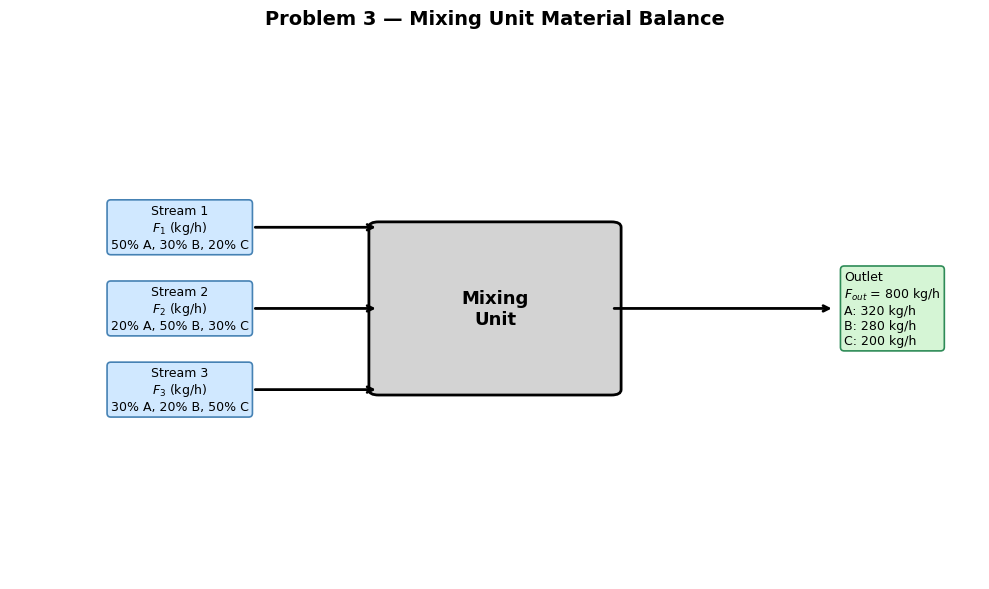

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# ── Mixing box ────────────────────────────────────────────────────────────────
box = mpatches.FancyBboxPatch((3.8, 3.5), 2.4, 3.0,
                               boxstyle="round,pad=0.1",
                               linewidth=2, edgecolor='black',
                               facecolor='lightgray')
ax.add_patch(box)
ax.text(5.0, 5.0, 'Mixing\nUnit', ha='center', va='center',
        fontsize=13, fontweight='bold')

# ── Helper: draw an arrow ─────────────────────────────────────────────────────
def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# ── Feed streams (left side) ──────────────────────────────────────────────────
stream_data = [
    (1, 6.5, 'Stream 1\n$F_1$ (kg/h)\n50% A, 30% B, 20% C'),
    (1, 5.0, 'Stream 2\n$F_2$ (kg/h)\n20% A, 50% B, 30% C'),
    (1, 3.5, 'Stream 3\n$F_3$ (kg/h)\n30% A, 20% B, 50% C'),
]

for (x_start, y_start, label) in stream_data:
    arrow(ax, x_start + 1.5, y_start, 3.8, y_start)
    ax.text(x_start + 0.75, y_start, label, ha='center', va='center',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='#d0e8ff', edgecolor='steelblue', lw=1.2))

# ── Outlet stream (right side) ────────────────────────────────────────────────
arrow(ax, 6.2, 5.0, 8.5, 5.0)
ax.text(8.6, 5.0,
        'Outlet\n$F_{out}$ = 800 kg/h\nA: 320 kg/h\nB: 280 kg/h\nC: 200 kg/h',
        ha='left', va='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#d5f5d5',
                  edgecolor='seagreen', lw=1.2))

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title('Problem 3 — Mixing Unit Material Balance', fontsize=14,
             fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

**Tasks:**

a) **(10 pts)** Solve for F₁, F₂, F₃

In [24]:
import numpy as np

# System:  A * [F1, F2, F3]^T = b
#
#  Row 1 (total mass):      F1 + F2 + F3 = 800
#  Row 2 (component A):  0.5*F1 + 0.2*F2 + 0.3*F3 = 320
#  Row 3 (component B):  0.3*F1 + 0.5*F2 + 0.2*F3 = 280

A = np.array([[1.0,  1.0,  1.0],
              [0.5,  0.2,  0.3],
              [0.3,  0.5,  0.2]])

b = np.array([800.0, 320.0, 280.0])

print("Coefficient matrix A:")
print(A)
print("\nRight-hand side vector b:", b)

x = np.linalg.solve(A, b)
F1, F2, F3 = x

print(f"F1 = {F1:.2f} kg/h")
print(f"F2 = {F2:.2f} kg/h")
print(f"F3 = {F3:.2f} kg/h")

Coefficient matrix A:
[[1.  1.  1. ]
 [0.5 0.2 0.3]
 [0.3 0.5 0.2]]

Right-hand side vector b: [800. 320. 280.]
F1 = 514.29 kg/h
F2 = 228.57 kg/h
F3 = 57.14 kg/h


b) **(10 pts)** Verify that component C balance is satisfied (should equal 200 kg/h) and check that all flow rates are positive and physically meaningful

In [15]:
# Component C balance: 0.20*F1 + 0.30*F2 + 0.50*F3 should equal 200 kg/h
C_flow = 0.20*F1 + 0.30*F2 + 0.50*F3
print(f"Component C flow rate:  {C_flow:.4f} kg/h  (expected 200 kg/h)")
print(f"Balance satisfied: {np.isclose(C_flow, 200.0)}")

# Check physical meaningfulness
print("\nPhysical check (all flow rates must be positive):")
for i, F in enumerate([F1, F2, F3], start=1):
    status = "OK" if F > 0 else "INVALID (negative!)"
    print(f"  F{i} = {F:.2f} kg/h  → {status}")

Component C flow rate:  200.0000 kg/h  (expected 200 kg/h)
Balance satisfied: True

Physical check (all flow rates must be positive):
  F1 = 514.29 kg/h  → OK
  F2 = 228.57 kg/h  → OK
  F3 = 57.14 kg/h  → OK


---
## Problem 3 (30 points): Arrhenius Analysis — Extracting Kinetic Parameters from Data

The **Arrhenius equation** describes how reaction rate constants vary with temperature:

$$
k = A \, e^{-E_a / (RT)}
$$

Taking the natural log linearizes this:

$$
\ln k = \ln A - \frac{E_a}{R} \cdot \frac{1}{T}
$$

So a plot of $\ln k$ vs $1/T$ should be a straight line with **slope** $= -E_a/R$ and **intercept** $= \ln A$.

A laboratory measured the following rate constants for the decomposition of N₂O₅:

| T (K) | k (s⁻¹) |
|-------|---------|
| 273 | 7.87 × 10⁻⁷ |
| 298 | 3.46 × 10⁻⁵ |
| 318 | 4.98 × 10⁻⁴ |
| 338 | 4.87 × 10⁻³ |
| 358 | 3.50 × 10⁻² |

**Tasks:**

a) (20 pts) Create an **Arrhenius plot**: $\ln k$ vs $1/T$ (×10³ for readability on the x-axis). Print $E_a$ (kJ/mol) and $A$ (s⁻¹) clearly with units.

b) (10 pts) **In a markdown cell below your code**, write 2–3 sentences: *What does a higher $E_a$ physically mean for a reaction? Based on your fitted $E_a$, is the N₂O₅ decomposition highly temperature-sensitive?*

Activation energy:    Ea = 102.60 kJ/mol
Pre-exponential factor: A = 3.4111e+13 s⁻¹


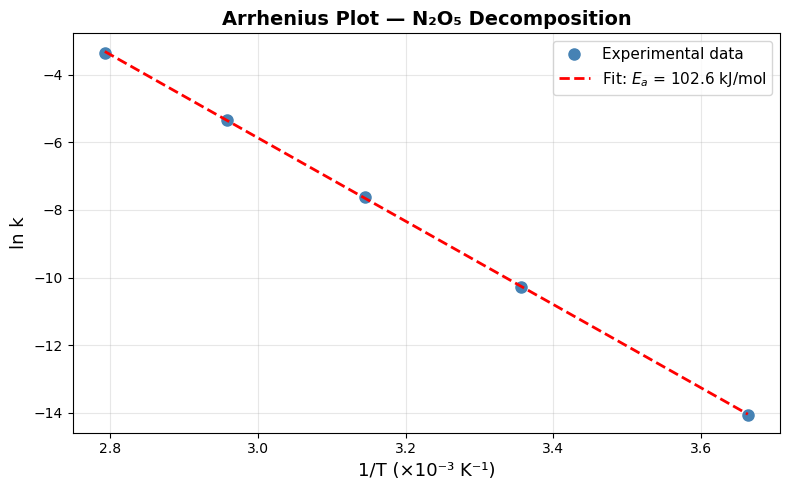

In [19]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.314   # J/(mol·K)

# Task 1: Data
T_data = np.array([273, 298, 318, 338, 358])          # K
k_data = np.array([7.87e-7, 3.46e-5, 4.98e-4, 4.87e-3, 3.50e-2])  # s^-1

# Task 2: Linearize
inv_T = 1 / T_data          # K^-1
ln_k  = np.log(k_data)      # dimensionless

# Task 3: Arrhenius fit
coeffs    = np.polyfit(inv_T, ln_k, 1)
slope, intercept = coeffs

Ea = -slope * R / 1000      # kJ/mol  (slope = -Ea/R)
A  = np.exp(intercept)      # s^-1

# Task 5: Print results
print(f"Activation energy:    Ea = {Ea:.2f} kJ/mol")
print(f"Pre-exponential factor: A = {A:.4e} s⁻¹")

# Task 4: Arrhenius plot
inv_T_fit = np.linspace(inv_T.min(), inv_T.max(), 200)
ln_k_fit  = slope * inv_T_fit + intercept

plt.figure(figsize=(8, 5))
plt.plot(inv_T * 1e3, ln_k,
         'o', color='steelblue', markersize=8, label='Experimental data')
plt.plot(inv_T_fit * 1e3, ln_k_fit,
         'r--', linewidth=2, label=f'Fit: $E_a$ = {Ea:.1f} kJ/mol')
plt.xlabel('1/T (×10⁻³ K⁻¹)', fontsize=13)
plt.ylabel('ln k', fontsize=13)
plt.title('Arrhenius Plot — N₂O₅ Decomposition', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Physical interpretation:**

A higher $E_a$ means reactant molecules must overcome a larger energy barrier to form products — at low temperatures, very few collisions carry sufficient energy, so the rate constant is small. As temperature rises, the fraction of energetic collisions grows exponentially (per the Boltzmann distribution), causing $k$ to increase rapidly. For N₂O₅ decomposition, the fitted $E_a \approx 103$ kJ/mol is moderately high, confirming the reaction is highly temperature-sensitive: the rate constant increases by nearly **four orders of magnitude** (from ~10⁻⁷ to ~10⁻² s⁻¹) over just an 85 K rise in temperature.

---

**Point Distribution:**
- Problem 1: 30 pts
- Problem 2: 20 pts
- Problem 3: 30 pts
- **Total: 80 pts)**

Good luck!